Grade başına (sadece aktif) benzersiz SpecGroupId sayısı:
 Grade
DX51D+Z       504
S235JR        222
S350GD+Z      111
DX51DT+Z      111
DD11           85
S280GD+Z       60
DD11-1         43
S250GD+Z       40
S320GD+Z       23
S220GD+Z       23
S235JR-1       21
DX52D+Z        17
S275JR         14
DD11-2         12
DX53D+Z         8
S355J2          6
P265NB          5
DD13            4
DX54D+Z         2
S235JR-CL3      2
S275J2          2
Name: SpecGroupId, dtype: int64

Her ayki aktif SpecGroupId sayısı:
 Month
2024-01-01    239
2024-02-01    221
2024-03-01    251
2024-04-01    186
2024-05-01    221
2024-06-01    219
2024-07-01    177
2024-08-01    213
2024-09-01    172
2024-10-01    187
2024-11-01    179
2024-12-01    144
Name: SpecGroupId, dtype: int64


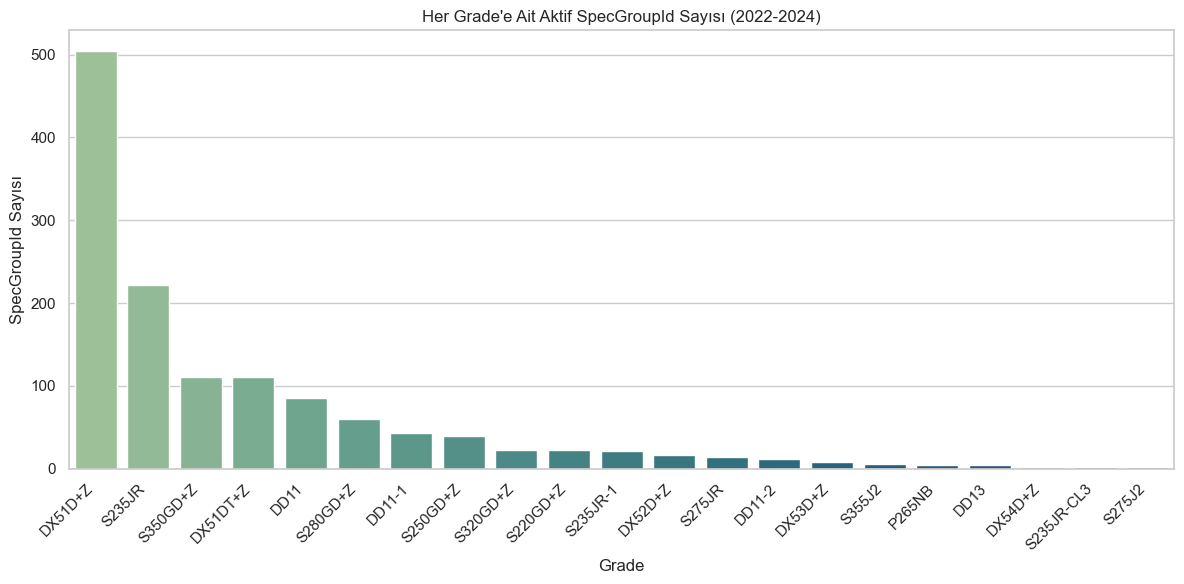

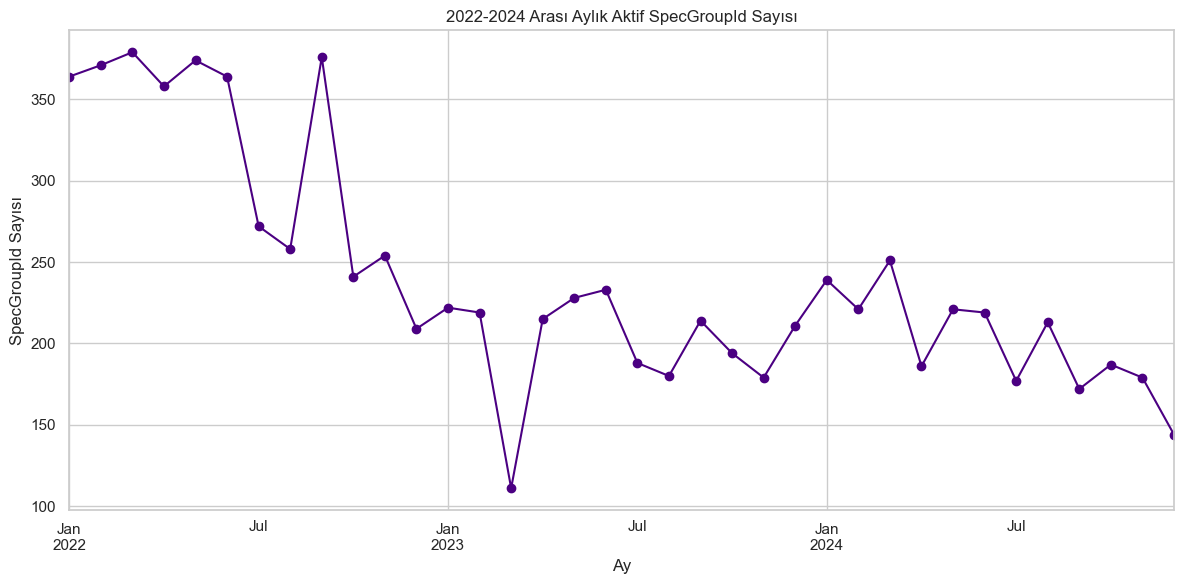

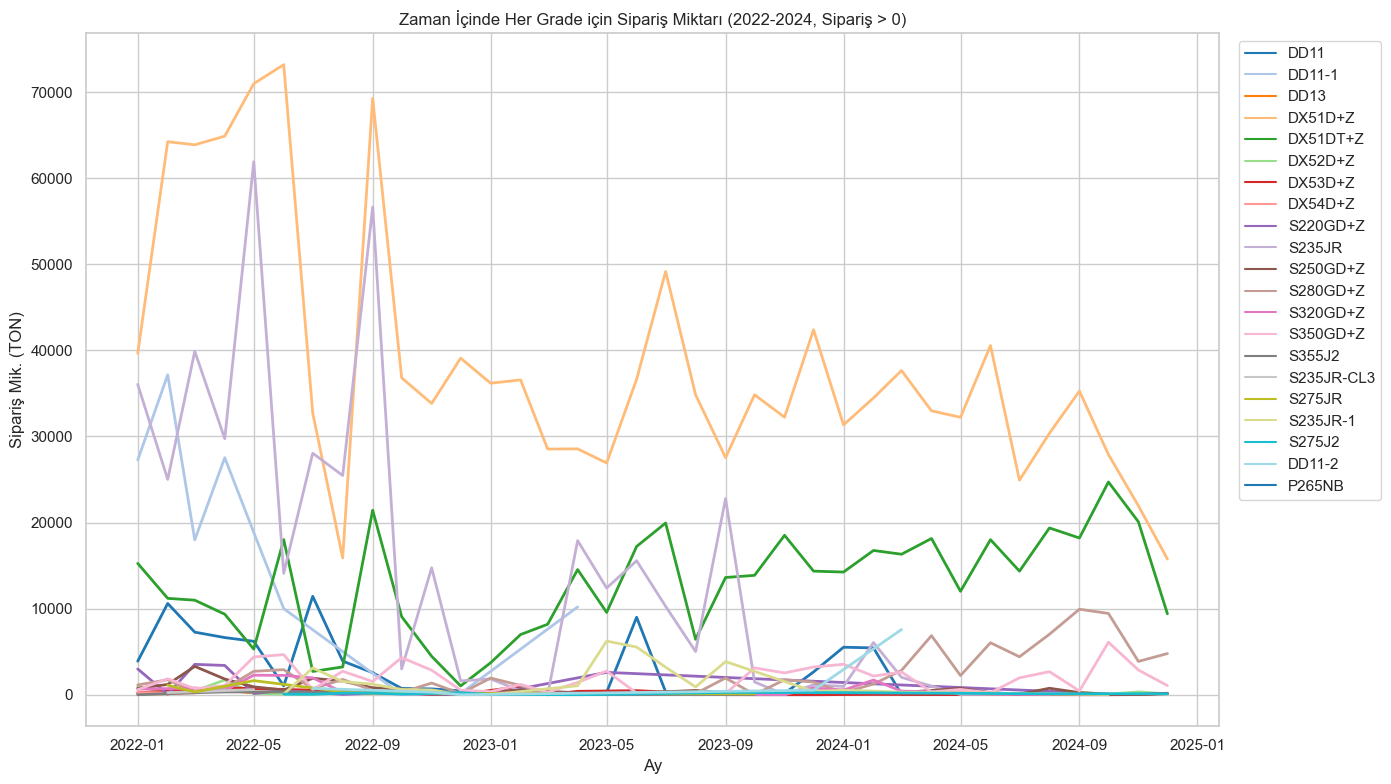

In [1]:
# Gerekli kütüphaneler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter ayarları
%matplotlib inline
sns.set(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

# 1. VERİYİ YÜKLE
df = pd.read_excel('preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx')
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']

# 2. VERİYİ DÜZENLE
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 3. ZAMAN FİLTRESİ (2022-01 ~ 2024-12) ve Sipariş miktarı > 0 filtrelemesi
df = df[(df['Month'] >= '2022-01-01') & (df['Month'] <= '2024-12-31')]
df_nonzero = df[df['Sipariş Mik. (TON)'] > 0]

# 4. Grade başına kaç farklı aktif SpecGroupId var (siparişi olanlar)
spec_count_per_grade = df_nonzero.groupby('Grade')['SpecGroupId'].nunique().sort_values(ascending=False)
print("Grade başına (sadece aktif) benzersiz SpecGroupId sayısı:\n", spec_count_per_grade)

# 5. Her ay kaç farklı SpecGroupId aktif (siparişi olan)?
monthly_spec_count = df_nonzero.groupby('Month')['SpecGroupId'].nunique()
print("\nHer ayki aktif SpecGroupId sayısı:\n", monthly_spec_count.tail(12))

# 6. Grade başına SpecGroupId sayısı (Bar plot)
plt.figure(figsize=(12, 6))
sns.barplot(x=spec_count_per_grade.index, y=spec_count_per_grade.values, palette='crest')
plt.xticks(rotation=45, ha='right')
plt.title("Her Grade'e Ait Aktif SpecGroupId Sayısı (2022-2024)")
plt.ylabel("SpecGroupId Sayısı")
plt.xlabel("Grade")
plt.tight_layout()
plt.show()

# 7. Aylık aktif SpecGroupId sayısı (Line plot)
plt.figure(figsize=(12, 6))
monthly_spec_count.plot(marker='o', linestyle='-', color='indigo')
plt.title("2022-2024 Arası Aylık Aktif SpecGroupId Sayısı")
plt.ylabel("SpecGroupId Sayısı")
plt.xlabel("Ay")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Her Grade’in zaman içinde toplam sipariş trendi
monthly_grade = df_nonzero.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(data=monthly_grade, x='Month', y='Sipariş Mik. (TON)', hue='Grade', linewidth=2, palette='tab20')
plt.title("Zaman İçinde Her Grade için Sipariş Miktarı (2022-2024, Sipariş > 0)")
plt.xlabel("Ay")
plt.ylabel("Sipariş Mik. (TON)")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()




In [2]:
# 9. SADECE 2024-AĞUSTOS ~ ARALIK VERİLERİ (Sipariş > 0)
df_test = df_nonzero[(df_nonzero['Month'] >= '2022-01-01') & (df_nonzero['Month'] <= '2024-12-31')]

# Her ay aktif SpecGroupId sayısı ve toplam sipariş miktarı
test_summary = df_test.groupby('Month').agg(
    Aktif_SpecGroupId_Sayısı=('SpecGroupId', 'nunique'),
    Toplam_Sipariş_TON=('Sipariş Mik. (TON)', 'sum')
).reset_index()

print("\n📅 2024-Ağustos ~ Aralık Aylarına Ait Özet:")
print(test_summary)



📅 2024-Ağustos ~ Aralık Aylarına Ait Özet:
        Month  Aktif_SpecGroupId_Sayısı  Toplam_Sipariş_TON
0  2022-01-01                       364          129,711.68
1  2022-02-01                       371          154,838.76
2  2022-03-01                       379          150,658.53
3  2022-04-01                       358          149,034.49
4  2022-05-01                       374          176,290.07
5  2022-06-01                       364          127,442.90
6  2022-07-01                       272           84,079.83
7  2022-08-01                       258           57,202.81
8  2022-09-01                       376          155,409.35
9  2022-10-01                       241           58,037.33
10 2022-11-01                       254           59,203.50
11 2022-12-01                       209           43,733.60
12 2023-01-01                       222           44,540.11
13 2023-02-01                       219           48,122.42
14 2023-03-01                       111           37,222

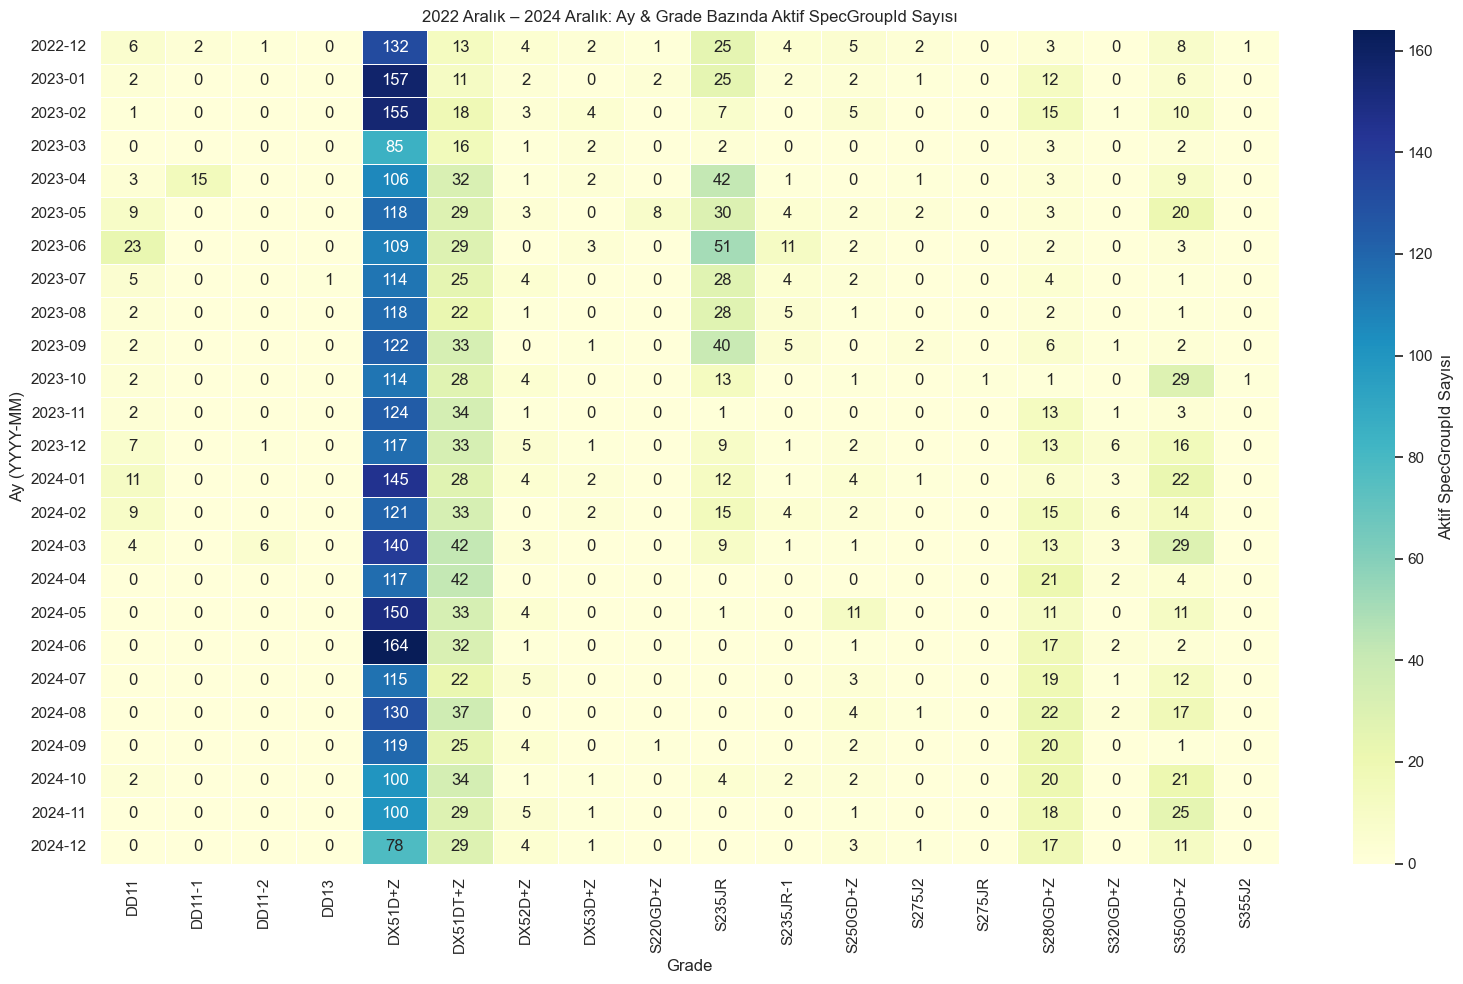

In [3]:
# 🔍 Son 25 ayı filtrele (2022-12 ~ 2024-12, sipariş > 0 olanlar)
df_last25 = df_nonzero[(df_nonzero['Month'] >= '2022-12-01') & (df_nonzero['Month'] <= '2024-12-31')]

# 📊 Pivot tablo: Ay x Grade => Aktif SpecGroupId sayısı
heatmap_data = df_last25.groupby(['Month', 'Grade'])['SpecGroupId'].nunique().reset_index()
heatmap_pivot = heatmap_data.pivot(index='Month', columns='Grade', values='SpecGroupId').fillna(0).astype(int)

# 📅 Ayları YYYY-MM formatına dönüştür
heatmap_pivot.index = pd.to_datetime(heatmap_pivot.index).to_period('M').astype(str)

# 🎨 Heatmap çizimi
plt.figure(figsize=(16, 10))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Aktif SpecGroupId Sayısı'}
)
plt.title("2022 Aralık – 2024 Aralık: Ay & Grade Bazında Aktif SpecGroupId Sayısı")
plt.xlabel("Grade")
plt.ylabel("Ay (YYYY-MM)")
plt.tight_layout()
plt.show()



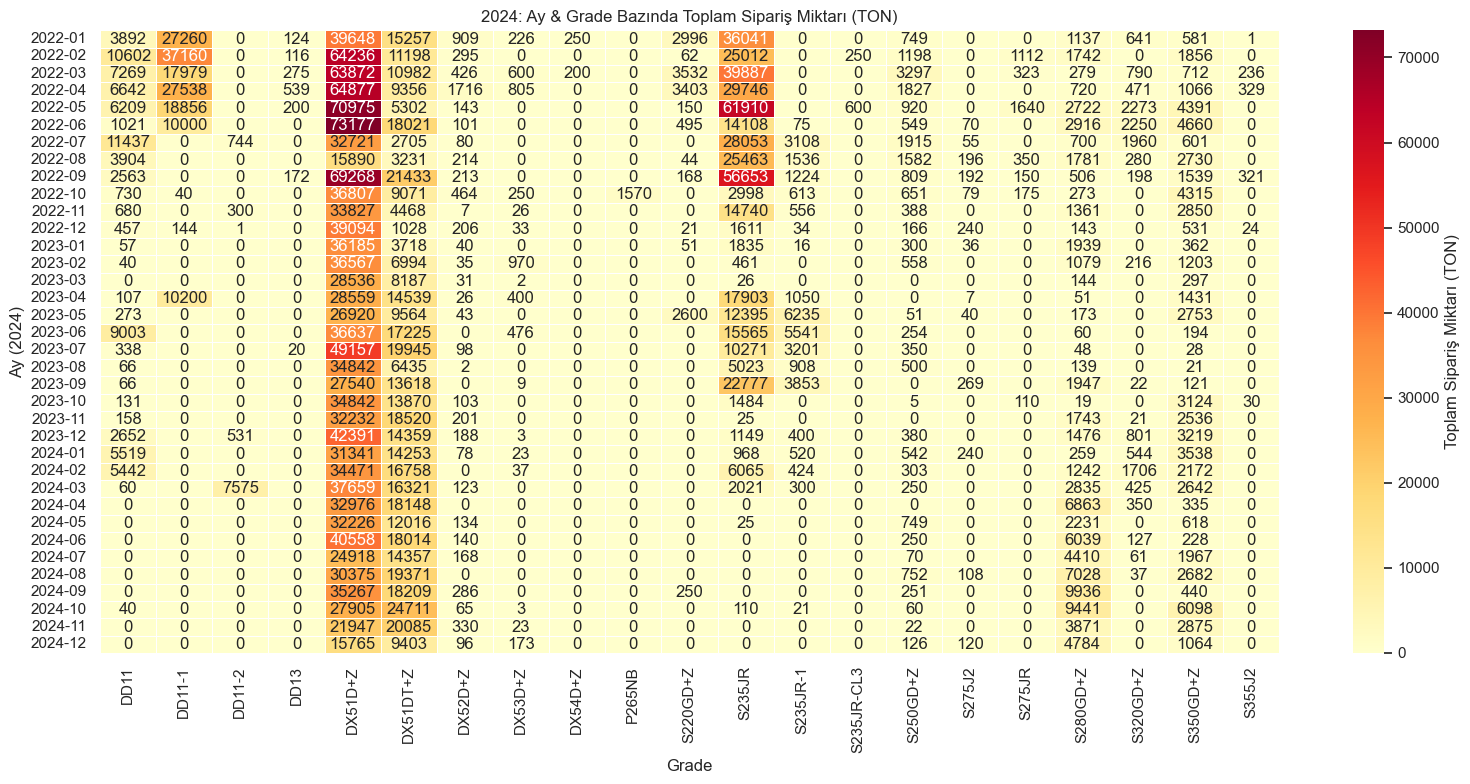

In [4]:
# 🔍 2024 yılı verisi (sadece sipariş > 0 olanlar)
df_2024 = df_nonzero[(df_nonzero['Month'] >= '2022-01-01') & (df_nonzero['Month'] <= '2024-12-31')]

# 📊 Pivot tablo: Ay x Grade => Toplam Sipariş Miktarı (TON)
siparis_data_2024 = df_2024.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()
siparis_pivot_2024 = siparis_data_2024.pivot(index='Month', columns='Grade', values='Sipariş Mik. (TON)').fillna(0)

# 📅 Ayları sadece YYYY-MM formatında göster
siparis_pivot_2024.index = siparis_pivot_2024.index.to_period('M').astype(str)

# 🎨 Heatmap çizimi: Sipariş Miktarı
plt.figure(figsize=(16, 8))
sns.heatmap(
    siparis_pivot_2024,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Toplam Sipariş Miktarı (TON)'}
)
plt.title("2024: Ay & Grade Bazında Toplam Sipariş Miktarı (TON)")
plt.xlabel("Grade")
plt.ylabel("Ay (2024)")
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import plotly.graph_objects as go

# 🔹 1. Veri Yükleme
df = pd.read_excel("preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx")
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 🔹 2. Filtreleme
df_nonzero = df[(df['Sipariş Mik. (TON)'] > 0) &
                (df['Month'] >= '2022-01-01') & 
                (df['Month'] <= '2024-12-31')].copy()
df_nonzero['MonthStr'] = df_nonzero['Month'].dt.to_period('M').astype(str)

# 🔹 3. Aylar ve Grade'ler
unique_months = sorted(df_nonzero['MonthStr'].unique())
all_grades = sorted(df_nonzero['Grade'].unique())

# 🔹 4. Boş figür oluştur ve tüm Grade’leri legendonly olarak başlat
fig = go.Figure()
for grade in all_grades:
    fig.add_trace(go.Bar(
        x=[], y=[], name=grade,
        visible='legendonly',
        marker_line=dict(width=1.2, color='black')
    ))

# 🔹 5. Dropdown butonları
dropdown_buttons = []
for month in unique_months:
    df_m = df_nonzero[df_nonzero['MonthStr'] == month]
    trace_x = []
    trace_y = []
    visibility = []

    for grade in all_grades:
        df_g = df_m[df_m['Grade'] == grade]
        trace_x.append(df_g['SpecGroupId'].tolist())
        trace_y.append(df_g['Sipariş Mik. (TON)'].tolist())
        visibility.append('legendonly')  # Her seferinde pasif başlasın

    button = dict(
        method='update',
        label=month,
        args=[
            {"x": trace_x, "y": trace_y, "visible": visibility},
            {"title": f"Tüm SpecGroupId'ler – {month}"}
        ]
    )
    dropdown_buttons.append(button)

# 🔹 6. Layout ayarları
fig.update_layout(
    title=f"Tüm SpecGroupId'ler – {unique_months[0]}",
    updatemenus=[dict(
        buttons=dropdown_buttons,
        direction="down",
        showactive=True,
        x=0.01,
        xanchor="left",
        y=1.08,
        yanchor="top"
    )],
    barmode='group',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black'),
    xaxis=dict(showgrid=True, gridcolor='lightgrey', tickangle=45),
    yaxis=dict(showgrid=True, gridcolor='lightgrey'),
    height=600,
    margin=dict(t=100)
)

fig.show()


In [2]:

import pandas as pd
import plotly.graph_objects as go

# 1. VERİYİ YÜKLE
df = pd.read_excel("preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx")
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. FİLTRELE
df = df[
    (df['Sipariş Mik. (TON)'] > 0) &
    (df['Month'] >= '2022-01-01') &
    (df['Month'] <= '2024-12-31')
].copy()
df['MonthStr'] = df['Month'].dt.to_period('M').astype(str)

# 3. PARETO ANALİZİ
results = []

for (month, grade), group in df.groupby(['MonthStr', 'Grade']):
    sorted_df = group.sort_values(by='Sipariş Mik. (TON)', ascending=False)
    total = sorted_df['Sipariş Mik. (TON)'].sum()
    sorted_df['Cumulative'] = sorted_df['Sipariş Mik. (TON)'].cumsum()
    sorted_df['CumulativePct'] = sorted_df['Cumulative'] / total
    spec80_count = (sorted_df['CumulativePct'] <= 0.80).sum()

    results.append({
        'Month': month,
        'Grade': grade,
        'TopSpecGroupCount_for80pct': spec80_count,
        'TotalSpecGroupCount': group['SpecGroupId'].nunique(),
        'ParetoPct': spec80_count / group['SpecGroupId'].nunique(),
        'TotalSiparis': total
    })

pareto_df = pd.DataFrame(results)

# 4. GRAFİK BAŞLANGICI
unique_months = pareto_df['Month'].unique()
initial_month = unique_months[0]
initial_data = pareto_df[pareto_df['Month'] == initial_month]

fig = go.Figure()

# 5. Başlangıç barları (bar genişliği layout'tan kontrol edilecek)
for _, row in initial_data.iterrows():
    fig.add_trace(go.Bar(
        x=[row['Grade']],
        y=[row['ParetoPct']],
        text=f"{row['TopSpecGroupCount_for80pct']} ürün (%{row['ParetoPct']*100:.1f})",
        textposition='outside',
        hovertemplate=
            f"<b>Grade: {row['Grade']}</b><br>" +
            f"Pareto Oranı: %{row['ParetoPct']*100:.1f}<br>" +
            f"{row['TopSpecGroupCount_for80pct']} / {row['TotalSpecGroupCount']} ürün<br>" +
            f"Toplam Sipariş: {row['TotalSiparis']:.0f} TON<br><extra></extra>"
    ))

# 6. DROPDOWN BUTONLARI
dropdown_buttons = []

for month in unique_months:
    df_m = pareto_df[pareto_df['Month'] == month]

    x_vals = [[row['Grade']] for _, row in df_m.iterrows()]
    y_vals = [[row['ParetoPct']] for _, row in df_m.iterrows()]
    texts = [f"{row['TopSpecGroupCount_for80pct']} ürün (%{row['ParetoPct']*100:.1f})" for _, row in df_m.iterrows()]
    hovertexts = [f"<b>Grade: {row['Grade']}</b><br>" +
                  f"Pareto Oranı: %{row['ParetoPct']*100:.1f}<br>" +
                  f"{row['TopSpecGroupCount_for80pct']} / {row['TotalSpecGroupCount']} ürün<br>" +
                  f"Toplam Sipariş: {row['TotalSiparis']:.0f} TON<br><extra></extra>"
                  for _, row in df_m.iterrows()]

    button = dict(
        method='update',
        label=month,
        args=[
            {'x': x_vals,
             'y': y_vals,
             'text': texts,
             'hovertemplate': hovertexts},
            {'title': f"{month} – Grade Bazlı Pareto Analizi"}
        ]
    )
    dropdown_buttons.append(button)

# 7. LAYOUT – bar genişliği burada kontrol ediliyor
fig.update_layout(
    title=f"{initial_month} – Grade Bazlı Pareto Analizi",
    updatemenus=[dict(
        buttons=dropdown_buttons,
        direction='down',
        showactive=True,
        x=0.01,
        xanchor='left',
        y=1.12,
        yanchor='top'
    )],
    barmode='group',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black'),
    xaxis=dict(title="Grade", showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(title="Pareto Oranı", tickformat=".0%", showgrid=True, gridcolor='lightgrey'),
    height=650,
    showlegend=False,
    margin=dict(t=120),
    bargap=0.2  # 🔥 barlar arası sabit boşluk – barlar düzgün kalınlıkta
)

fig.show()





In [4]:
import pandas as pd
import plotly.graph_objects as go

# 1. VERİYİ YÜKLE
df = pd.read_excel("preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx")
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# 2. FİLTRELE
df = df[
    (df['Sipariş Mik. (TON)'] > 0) &
    (df['Month'] >= '2022-01-01') &
    (df['Month'] <= '2024-12-31')
].copy()

# 3. TOPLAM PARETO ANALİZİ
results = []

for grade, group in df.groupby('Grade'):
    sorted_df = group.sort_values(by='Sipariş Mik. (TON)', ascending=False)
    total = sorted_df['Sipariş Mik. (TON)'].sum()
    sorted_df['Cumulative'] = sorted_df['Sipariş Mik. (TON)'].cumsum()
    sorted_df['CumulativePct'] = sorted_df['Cumulative'] / total

    # %80'e ulaşan ilk kaç satır var?
    spec80_count = (sorted_df['CumulativePct'] <= 0.8).sum()
    if not (sorted_df['CumulativePct'] <= 0.8).all():
        spec80_count += 1  # çünkü 0.8'i geçmek için bir satır daha lazım oluyor

    total_spec_count = group['SpecGroupId'].nunique()

    results.append({
        'Grade': grade,
        'TopSpecGroupCount_for80pct': spec80_count,
        'TotalSpecGroupCount': total_spec_count,
        'ParetoPct': spec80_count / total_spec_count,
        'TotalSiparis': total
    })

pareto_df = pd.DataFrame(results)

# 4. GRAFİK
fig = go.Figure()

for _, row in pareto_df.iterrows():
    fig.add_trace(go.Bar(
        x=[row['Grade']],
        y=[row['ParetoPct']],
        text=f"{row['TopSpecGroupCount_for80pct']} ürün (%{row['ParetoPct']*100:.1f})",
        textposition='outside',
        hovertemplate=
            f"<b>Grade: {row['Grade']}</b><br>" +
            f"Pareto Oranı: %{row['ParetoPct']*100:.1f}<br>" +
            f"{row['TopSpecGroupCount_for80pct']} / {row['TotalSpecGroupCount']} ürün<br>" +
            f"Toplam Sipariş: {row['TotalSiparis']:.0f} TON<br><extra></extra>"
    ))

fig.update_layout(
    title="Toplam – Grade Bazlı Pareto Analizi (Doğru Hesaplama)",
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black'),
    xaxis=dict(title="Grade", showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(title="Pareto Oranı", tickformat=".0%", showgrid=True, gridcolor='lightgrey'),
    height=650,
    showlegend=False,
    margin=dict(t=100),
    bargap=0.2
)

fig.show()
